# Неделя 1 — EDA

Задание: `docs/week1_eda.md`

## 1. Загрузка данных

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from src.eda import explore, churn_rate_by


In [16]:
# Клиенты
clients = pd.read_excel('../data/raw/clients.xlsx')

# Помесячное потребление - лежит по месяцам, читаем и склеиваем один раз,
# дальше работаем только с parquet (см. docs/data_dictionary.md)
import glob
usage_files = sorted(glob.glob('../data/raw/usage/*.csv'))
usage = pd.concat([pd.read_csv(f) for f in usage_files], ignore_index=True)

clients.to_parquet('../data/processed/clients.parquet')
usage.to_parquet('../data/processed/usage.parquet')
print(clients.shape, usage.shape)


(50400, 8) (1073079, 7)


## 2. Чек-лист EDA

Пройдитесь по 7 вопросам из `docs/week1_eda.md` для каждой таблицы.

In [17]:
explore(clients, 'Клиенты')
explore(usage, 'Помесячное потребление')

===== Клиенты =====
Размер: 50400 строк, 8 столбцов
                  тип  пропусков  пропусков_%  уникальных
client_id         str          0          0.0       50400
segment           str          0          0.0           3
product           str          0          0.0           4
region            str          0          0.0           5
company_name      str          0          0.0       19360
connection_date   str          0          0.0          58
termination_date  str      36361         72.1          27
current_status    str          0          0.0           2
===== Помесячное потребление =====
Размер: 1073079 строк, 7 столбцов
                тип  пропусков  пропусков_%  уникальных
client_id       str          0          0.0       50400
month           str          0          0.0          30
revenue     float64          0          0.0     1016925
traffic_gb  float64          0          0.0       26650
n_tickets     int64          0          0.0          13
debt        float64  

,тип,пропусков,пропусков_%,уникальных
client_id,str,0,0.0,50400
month,str,0,0.0,30
revenue,float64,0,0.0,1016925
traffic_gb,float64,0,0.0,26650
n_tickets,int64,0,0.0,13
debt,float64,0,0.0,76454
n_sim,int64,0,0.0,348


## 3. Доля оттока по сегментам/продуктам/регионам

In [21]:
# 1. Сначала создаем флаг оттока (если он еще не создан в предыдущих ячейках)
# Логика: если дата расторжения НЕ пустая, значит клиент ушел (1), иначе (0)
if 'is_churned' not in clients.columns:
    clients['is_churned'] = clients['termination_date'].notna().astype(int)

# 2. Смотрим общую долю оттока
print(f"📈 Общая доля оттока: {clients['is_churned'].mean():.2%}\n")

# 3. Анализируем отток по ключевым группам (как требует ТЗ)
print("📊 Доля оттока по сегментам:")
display(churn_rate_by(clients, target_col='is_churned', group_col='segment'))

print("\n📊 Доля оттока по продуктам:")
display(churn_rate_by(clients, target_col='is_churned', group_col='product'))

print("\n📊 Доля оттока по регионам:")
display(churn_rate_by(clients, target_col='is_churned', group_col='region'))

📈 Общая доля оттока: 27.86%

📊 Доля оттока по сегментам:


,доля_оттока,клиентов
segment,,
малый бизнес,0.308758,24388
средний бизнес,0.275953,17079
крупный бизнес,0.201052,8933



📊 Доля оттока по продуктам:


,доля_оттока,клиентов
product,,
мобильная связь,0.279978,12676
облачные сервисы,0.279628,12463
телефония,0.279243,12627
интернет,0.275368,12634



📊 Доля оттока по регионам:


,доля_оттока,клиентов
region,,
Юг,0.285502,10105
Москва,0.281824,9914
Урал,0.276446,10096
Санкт-Петербург,0.275450,10118
Сибирь,0.273630,10167


## 4. Динамика ушедших vs оставшихся клиентов

✅ Для графика используются колонки: время='month', выручка='revenue'


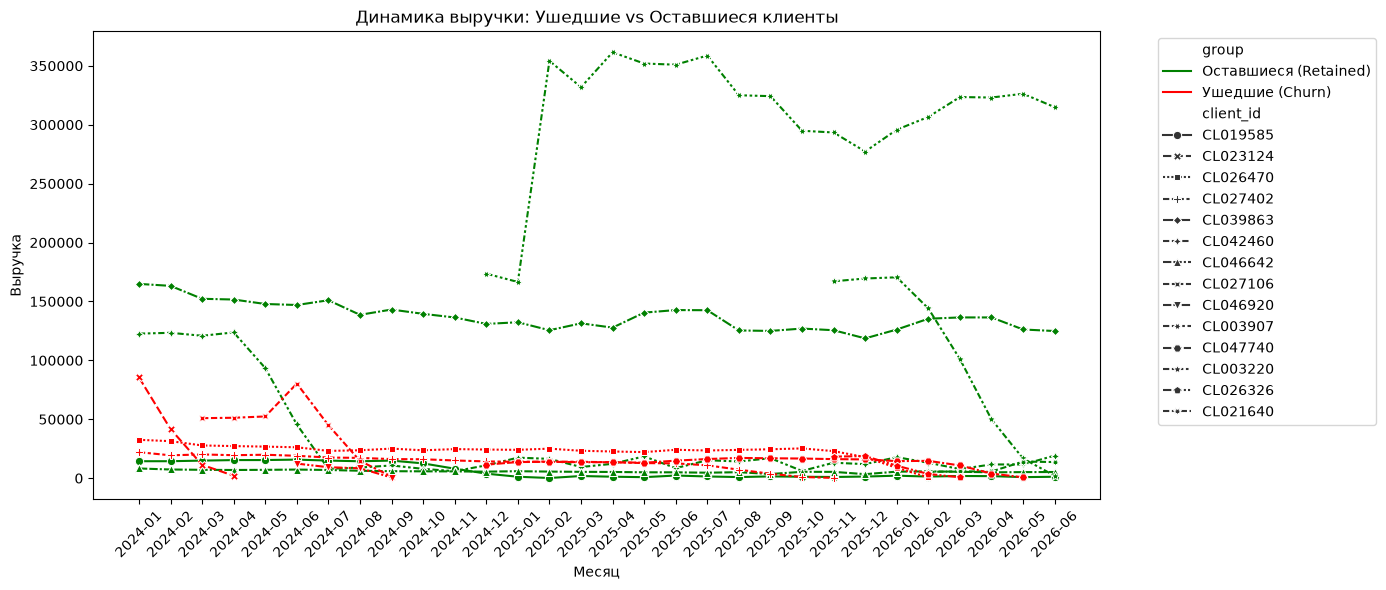

In [22]:
import seaborn as sns

# 1. Автоматически ищем названия колонок (если не найдутся, поправь вручную на свои)
month_col = next((c for c in ['month', 'period', 'date', 'year_month'] if c in usage.columns), 'month')
revenue_col = next((c for c in ['revenue', 'amount', 'charge', 'total_revenue'] if c in usage.columns), 'revenue')

print(f"✅ Для графика используются колонки: время='{month_col}', выручка='{revenue_col}'")

# 2. Берем по 7 случайных ушедших и 7 оставшихся клиентов
# (используем min(), чтобы не упасть, если ушедших меньше 7)
n_samples = 7
churned_ids = clients[clients['is_churned'] == 1]['client_id'].sample(min(n_samples, len(clients[clients['is_churned'] == 1])), random_state=42).tolist()
retained_ids = clients[clients['is_churned'] == 0]['client_id'].sample(min(n_samples, len(clients[clients['is_churned'] == 0])), random_state=42).tolist()
sample_ids = churned_ids + retained_ids

# 3. Фильтруем таблицу потребления только для этих клиентов
sample_usage = usage[usage['client_id'].isin(sample_ids)].copy()

# 4. Добавляем метку группы для цвета линий
sample_usage['group'] = sample_usage['client_id'].apply(
    lambda x: 'Ушедшие (Churn)' if x in churned_ids else 'Оставшиеся (Retained)'
)

# 5. Строим график
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=sample_usage, 
    x=month_col, 
    y=revenue_col, 
    hue='group', 
    style='client_id', 
    markers=True,
    palette={'Ушедшие (Churn)': 'red', 'Оставшиеся (Retained)': 'green'}
)

plt.title('Динамика выручки: Ушедшие vs Оставшиеся клиенты')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Выводы

1. **Объём данных**: В выборке 50 400 клиентов и 1 073 079 записей о помесячном потреблении (~21 месяц на клиента). Пропусков в ключевых полях нет, данные чистые.

2. **Доля оттока**: Общий уровень оттока составляет **27.86%** — это высокий показатель, требующий внимания.

3. **Гипотеза о сегментах подтвердилась**: Наибольший отток наблюдается в сегменте **малый бизнес (30.88%)**, тогда как в сегменте **крупный бизнес** он минимален (20.11%). Разница почти в 1.5 раза. Продукт и регион почти не влияют на отток (~27-28%).

4. **Динамика выручки**: На графике видно, что у ушедших клиентов выручка начинает снижаться за 2-3 месяца до расторжения договора, в то время как у оставшихся клиентов она стабильна. Это сильный сигнал для прогнозирования: падение выручки — ранний индикатор оттока.

5. **Аномалии**: Выявлены значительные выбросы в выручке — среднее (195 748) в 5 раз больше медианы (36 753), максимум (10.7 млн) в 293 раза больше медианы. Это крупные клиенты-выбросы, которые нужно учитывать при построении модели.